In [1]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine
from sklearn.linear_model import LinearRegression as LR
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("details_vector.csv",header=None)
df.columns=["AutoID","Author","Title","Max_layer","Read","Time",
           "Topic0","Topic1","Topic2","Topic3","Topic4","Topic5"]
df.head()
red_pocket_title=[u'下雨天宅家里？万元巨款你不准备要了吗！<长沙转发有礼>',
u'【周年店庆邀请函】丨点开有惊喜，转发有红包',
u'名匠心，设计情丨2017名匠杯设计大赛盛大启动',
u'【转发有惊喜】名匠心，设计情丨2017名匠杯设计大赛盛大启动',
u'年度特权日 装修特权价｜名匠2017年度【消费者特权日】盛大启幕',
u'眼要急！手要快！装修特权卡全城抢疯了',
u'开业特权 尊享钜惠 | 名匠装饰集团5家地市新店齐开',
u'国庆装修大动作！如此疯狂钜惠怎能错过？（前3000名转发有红包）',
u'抢定年度特权卡，装修钜惠更疯狂！']

In [3]:
data=[]
norm=[]
name=""
count=0
min_data=[]
max_read=0
min_read=0
red_pocket=[]
for index, row in df.iterrows():
    vec=np.array([float(row.Topic0),float(row.Topic1),float(row.Topic2),
                  float(row.Topic3),float(row.Topic4),float(row.Topic5)])
    if row.Title in red_pocket_title:
        red_pocket.append(1)
    else:
        red_pocket.append(0)
    if row.Author != name:   
        norm.extend([max_read-min_read]*count)
        min_data.extend([min_read]*count)
        name=row.Author
        count=1
        max_read=row.Read
        min_read=row.Read
        author_data=np.array([vec])
        data.append(None)
    else:
        count+=1
        max_read=max(row.Read,max_read)
        min_read=min(row.Read,min_read)
        avg=np.average(author_data,axis=0)
        sim=1-cosine(vec,avg)
        author_data=np.append(author_data,vec)
        data.append(sim)

norm.extend([max_read-min_read]*count)
min_data.extend([min_read]*count)

In [4]:
df["VecSim2His"]=data
df["Norm"]=norm
df["Min"]=min_data
df["Norm_read"]=np.log(df.Read+1)
df["Red_pocket"]=red_pocket
# df["Norm_read"]=(df.Read-df.Min)/df.Norm
df_red=df[df["Red_pocket"]>0]
df_nred=df[df["Red_pocket"]==0]

In [5]:
df.head()
df.to_csv("regression.csv",index=False,columns=["AutoID","Author","Title","Max_layer","Read","Time","VecSim2His","Norm_read","Red_pocket"])

In [7]:
df_r=df.dropna(axis=0,how='any')
df_red=df_red.dropna(axis=0,how='any')
df_nred=df_nred.dropna(axis=0,how='any')
df_r=pd.DataFrame(df_r,columns=['VecSim2His', 'Norm_read','Red_pocket'])
df_red=pd.DataFrame(df_red,columns=['VecSim2His', 'Norm_read','Red_pocket'])
df_nred=pd.DataFrame(df_nred,columns=['VecSim2His', 'Norm_read','Red_pocket'])
df.head()

,AutoID,Author,Title,Max_layer,Read,Time,Topic0,Topic1,Topic2,Topic3,Topic4,Topic5,VecSim2His,Norm,Min,Norm_read,Red_pocket
0,2277,+章珊,好的装修到底是什么样的，看看业主们是怎么说的！,2,11,2017-11-13 09:25:24,0.324923,0.579602,0.023849,0.023856,0.023921,0.023849,NaN,40,1,2.484907,0
1,2274,+章珊,“房子是用来住的”，好装修让您住得更舒适！,2,6,2017-11-13 09:27:29,0.441757,0.539671,0.004639,0.004645,0.004650,0.004638,0.983059,40,1,1.945910,0
2,2275,+章珊,名匠精工丨在名匠，为您家施工的到底是怎样一群人？,1,1,2017-11-14 00:09:43,0.001348,0.146842,0.001340,0.001343,0.001341,0.847787,0.474479,40,1,0.693147,0
3,2294,+章珊,装修新手，这五大家庭装修原则必须知道！,2,7,2017-11-16 14:57:35,0.001206,0.993972,0.001203,0.001206,0.001203,0.001210,0.410723,40,1,2.079442,0
4,2292,+章珊,自装？亲戚装？装饰公司装？终于有让人信服的答案了,2,41,2017-11-16 21:32:57,0.002671,0.030204,0.002662,0.002657,0.002654,0.959153,0.425417,40,1,3.737670,0


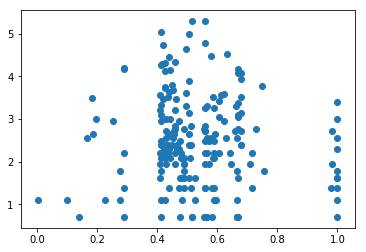

In [7]:
plt.scatter(df_r.VecSim2His[:200],df_r.Norm_read[:200],)

In [8]:
scipy.stats.pearsonr(df_red.VecSim2His, df_red.Norm_read)

(-0.03778684674834374, 0.16956126284087297)

In [9]:
scipy.stats.pearsonr(df_nred.VecSim2His, df_nred.Norm_read)

(-3.8306614021089116e-05, 0.9977735274521613)

In [10]:
scipy.stats.pearsonr(df_r.VecSim2His, df_r.Norm_read)

(-0.008671165784533976, 0.4801665631093244)

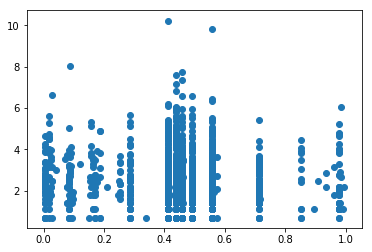

In [11]:
plt.scatter(df_red.VecSim2His,df_red.Norm_read)

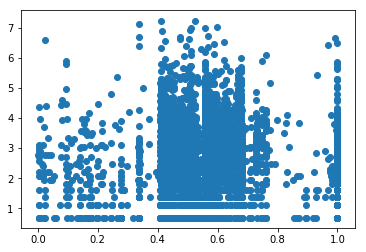

In [12]:
plt.scatter(df_nred.VecSim2His,df_nred.Norm_read)

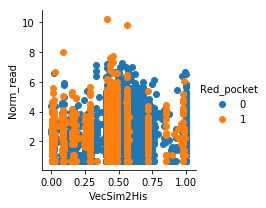

In [13]:
fg = sns.FacetGrid(data=df_r, hue='Red_pocket', hue_order=[0,1])
fg.map(plt.scatter, 'VecSim2His', 'Norm_read').add_legend()
plt.show()

In [14]:
df_p1=df[df["Author"]==u"曾小纾"]

In [15]:
df_p1.head()

,AutoID,Author,Title,Max_layer,Read,Time,Topic0,Topic1,Topic2,Topic3,Topic4,Topic5,VecSim2His,Norm,Min,Norm_read,Red_pocket
2907,839,曾小纾,名匠装饰15周年店庆，2000万豪礼等您拿！,3,23,2017-06-28 11:26:46,0.455564,0.320200,0.027778,0.028014,0.028157,0.140288,NaN,74,1,3.178054,0
2908,838,曾小纾,名匠精工丨在名匠，为您家施工的到底是怎样一群人？,1,1,2017-06-28 11:39:56,0.001348,0.146842,0.001340,0.001343,0.001341,0.847787,0.336158,74,1,0.693147,0
2909,822,曾小纾,【名匠15周年店庆】丨全城亮，名匠火,1,1,2017-07-07 21:25:43,0.227246,0.001539,0.001543,0.503619,0.001539,0.264513,0.666447,74,1,0.693147,0
2910,837,曾小纾,名匠心，设计情丨2017名匠杯设计大赛盛大启动,4,63,2017-08-03 12:59:42,0.179261,0.813540,0.001797,0.001801,0.001804,0.001797,0.490057,74,1,4.158883,1
2911,835,曾小纾,名匠声音（一）丨整装要讲究，我们有话说！,2,9,2017-08-08 10:20:47,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,1.000000,74,1,2.302585,0


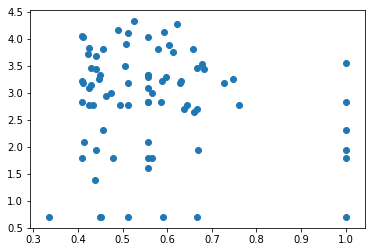

In [15]:
plt.scatter(df_p1.VecSim2His,df_p1.Norm_read)

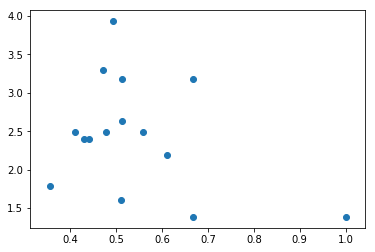

In [16]:
df_p2=df[df["Author"]==u"李盼"]
plt.scatter(df_p2.VecSim2His,df_p2.Norm_read)

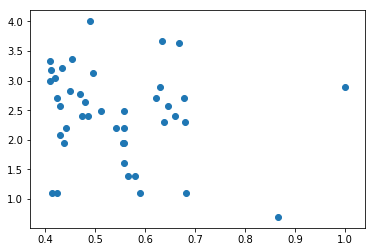

In [17]:
df_p3=df[df["Author"]==u"李祥"]
plt.scatter(df_p3.VecSim2His,df_p3.Norm_read)

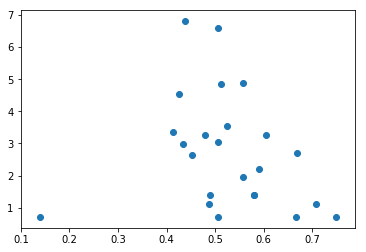

In [18]:
df_p4=df[df["Author"]==u"杨光"]
plt.scatter(df_p4.VecSim2His,df_p4.Norm_read)

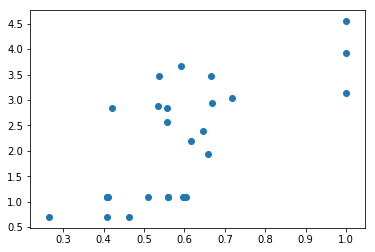

In [19]:
df_p5=df[df["Author"]==u"胡朝"]
plt.scatter(df_p5.VecSim2His,df_p5.Norm_read)

In [22]:
df.Author.unique()

array(['+章珊', '丁丽美', '丁壮志', '丁妮', '丁宇飞', '丁金雄', '万勇', '万宽', '万延和', '严丹',
       '严仁秋', '严佳琪', '义志伟', '乐春桃', '付智和', '代晶', '任凡', '任江平', '任花', '伍志霞',
       '伍柳枝', '伍洲', '伍海波', '伍胜', '何丹', '何利君', '何可欣', '何嘉奇', '何峰', '何思华',
       '何慧', '何斌', '何明明', '何武魁', '何波', '何源', '何焱', '何纯勇', '何美丽', '何舒琳',
       '何莎莎', '何赛', '余赛夫', '余静', '侯红光', '信和涛', '倪江平', '倪湾', '傅健', '傅雅丽',
       '全小辉', '全玲', '兰巧军', '冯丽', '冯令', '冯倩', '冯大鹏', '冯思思', '冯胜禄', '凌慧',
       '凌美丽', '刘三军', '刘三菊', '刘丹', '刘丽红', '刘亚平', '刘人瑞', '刘仁文', '刘伟', '刘伟顺',
       '刘佳宝', '刘侠', '刘保建', '刘信麟', '刘健', '刘兆东', '刘先梅', '刘光宇', '刘兵传', '刘凯',
       '刘双全', '刘君杰', '刘喻', '刘国文', '刘坤', '刘增科', '刘威', '刘娇', '刘娟', '刘宇',
       '刘小梅', '刘小芳', '刘少杰', '刘少龙', '刘平', '刘庆', '刘延丽', '刘德成', '刘志东', '刘志强',
       '刘志恒', '刘念', '刘恒', '刘慧婷', '刘才', '刘文文', '刘斌', '刘旺', '刘星', '刘智艳',
       '刘杰', '刘栋梁', '刘欧', '刘毅', '刘水林', '刘江南', '刘洋', '刘涛', '刘淯', '刘炯',
       '刘玉', '刘琴', '刘甜', '刘益', '刘真', '刘祥祖', '刘秀红', '刘纯', '刘羽', '刘若文',
       '刘英', '刘行恩', '刘超', '刘金花', '刘鑫', '刘雅希', '刘鹃', '包昌海'